In [1]:
#imports

import numpy as np
import matplotlib.pyplot as plt

from models.voltage_shift import *
from utils import *
from utils.iv_data import *
from utils.plotting import *

from builders.experimental_data import *

In [2]:
import os
print(f"I am currently looking in: {os.getcwd()}")
print(f"Does the folder exist here {os.path.exists('utils/iv_data')}")

I am currently looking in: c:\Users\aadig\Documents\Semiconductors\ferrodiode
Does the folder exist here True


Option 1) EXPERIMENTAL FED

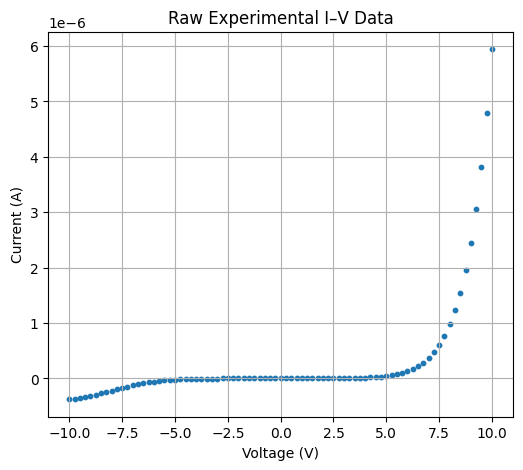

In [3]:
filename = "utils/iv_data/kim_2024/State1.csv"

curves = read_IV_csv(filename)

V = curves["voltage"]

I = next(I for k, I in curves.items() if k != "voltage")

plt.figure(figsize=(6,5))
plt.scatter(V, I, s=10)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Raw Experimental I–V Data")
plt.grid(True)
plt.show()

In [4]:
experimentalfed = FeD("experimental",file_csv=filename)

In [5]:
print(f"Voltage Shift: {experimentalfed.deltaV_V():.4f} V")

Voltage Shift: 1.5000 V


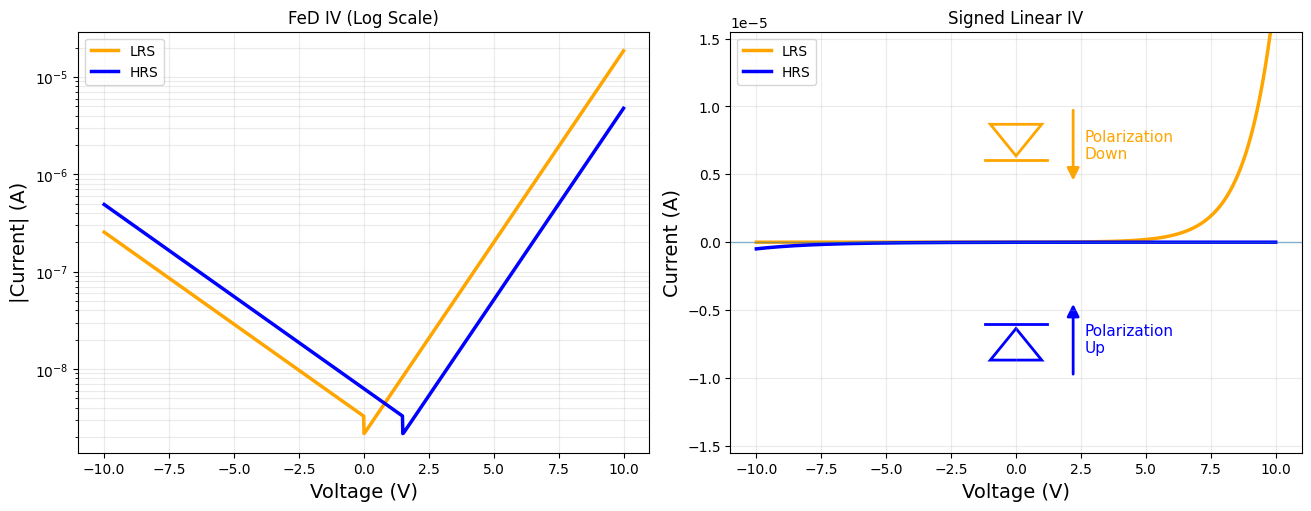

In [6]:
V = np.linspace(-10.0,10.0, 1500)
plot_fed(experimentalfed, V, show_signed=True)

Option 2) BASIC PARAMS

In [7]:
#input params

V_read = 8.0
V_write = 21.0
G_on = 1.0 / (75 * 1e9)
G_off = 1.0 / (135 * 1e9)
I_on = G_on * V_read
I_off = G_off * V_read
asym_G_LRS = 0.5
asym_a_LRS = 0.5
asym_G_HRS = 0.5
asym_a_HRS = 0.5
smoothing_voltage = 0.015

customs = {
    "V_read": V_read,
    "V_write": V_write,
    "G_on": G_on,
    "G_off": G_off,
    "I_on": I_on,
    "I_off": I_off,
    "asym_G_LRS": asym_G_LRS,
    "asym_a_LRS": asym_a_LRS,
    "asym_G_HRS": asym_G_HRS,
    "asym_a_HRS": asym_a_HRS,
    "smoothing_voltage": smoothing_voltage
}

basicfed = FeD("custom", **customs)

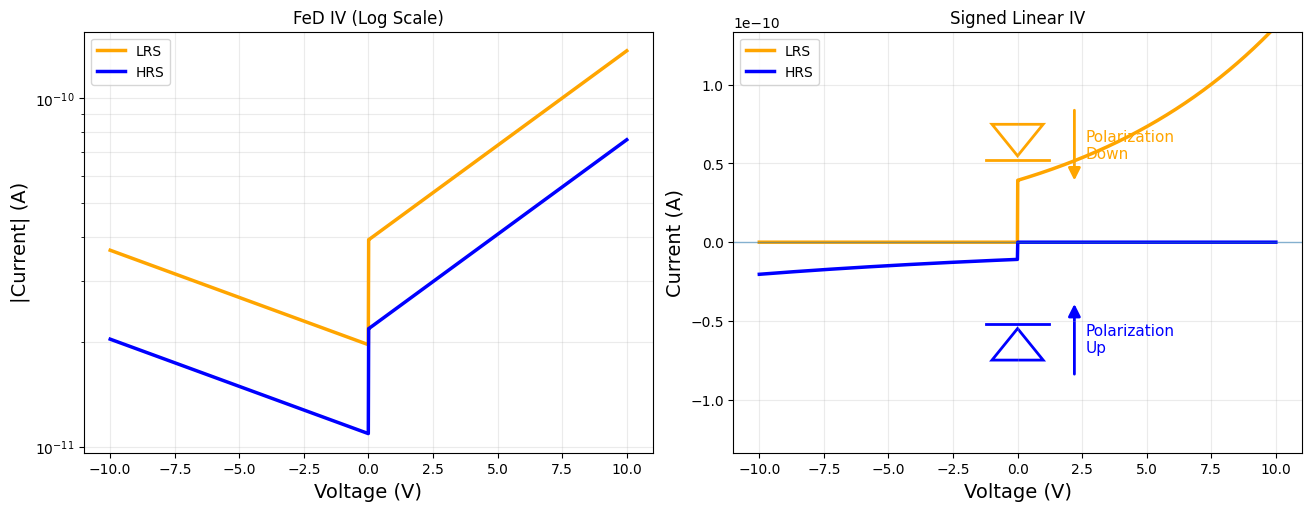

In [8]:
plot_fed(basicfed, V, show_signed=True)

Option 3) PRESET FEDs

In [9]:
kim2024fed = FeD("preset",preset_model="kim_2024")

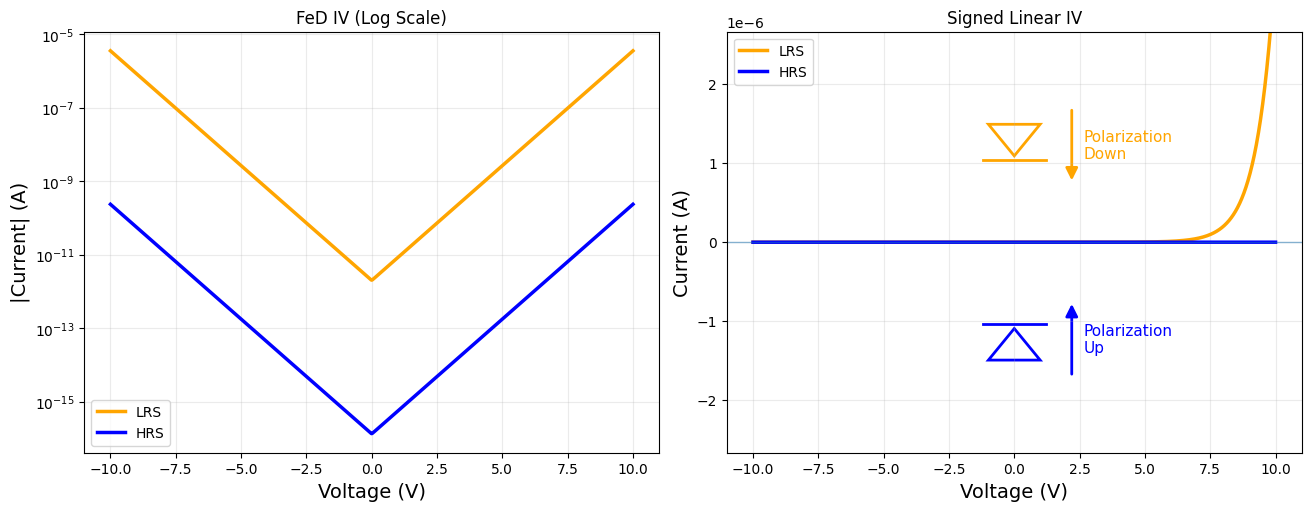

In [10]:
plot_fed(kim2024fed, V, show_signed=True)

In [14]:
def test_switching(fed):
    print("\n=== BASIC SWITCHING TEST ===")

    V_read = 0.5

    I0 = fed.read(V_read)
    print(f"Initial State: {fed.state}, I_read = {I0:.3e} A")

    switched = fed.write(+8.0, 10e-6)  # strong SET pulse
    I1 = fed.read(V_read)

    print(f"After +pulse → switched = {switched}, state = {fed.state}, I = {I1:.3e} A")

    switched = fed.write(-8.0, 10e-6)  # strong RESET pulse
    I2 = fed.read(V_read)

    print(f"After -pulse → switched = {switched}, state = {fed.state}, I = {I2:.3e} A")

    print(f"ON/OFF ratio ≈ {abs(I1/I2):.2e}")

In [15]:
test_switching(experimentalfed)
test_switching(basicfed)
test_switching(kim2024fed)


=== BASIC SWITCHING TEST ===
Initial State: HRS, I_read = 5.049e-09 A
After +pulse → switched = True, state = LRS, I = 3.373e-09 A
After -pulse → switched = True, state = HRS, I = 5.049e-09 A
ON/OFF ratio ≈ 6.68e-01

=== BASIC SWITCHING TEST ===
Initial State: HRS, I_read = 2.321e-11 A
After +pulse → switched = True, state = LRS, I = 4.177e-11 A
After -pulse → switched = True, state = HRS, I = 2.321e-11 A
ON/OFF ratio ≈ 1.80e+00

=== BASIC SWITCHING TEST ===
Initial State: HRS, I_read = 2.739e-16 A
After +pulse → switched = True, state = LRS, I = 4.108e-12 A
After -pulse → switched = True, state = HRS, I = 2.739e-16 A
ON/OFF ratio ≈ 1.50e+04
